In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
train = pd.read_csv("C:/Users/dilus/Downloads/DSPL docs/Hotel-A-train.csv")

print(train.shape)   # rows and columns
print(train.head())  # first 5 rows

(27499, 24)
   Reservation-id Gender  Age         Ethnicity Educational_Level  \
0        39428300      F   40            Latino              Grad   
1        77491756      F   49            Latino        Mid-School   
2        73747291      F   42         caucasian              Grad   
3        67301739      M   25  African American           College   
4        77222321      F   62            Latino       High-School   

        Income Country_region      Hotel_Type Expected_checkin  \
0         <25K          North      City Hotel         7/1/2015   
1  50K -- 100K           East      City Hotel         7/1/2015   
2         <25K           East      City Hotel         7/2/2015   
3        >100K          South  Airport Hotels         7/2/2015   
4    25K --50K           East          Resort         7/3/2015   

  Expected_checkout  ... Meal_Type  Visted_Previously  Previous_Cancellations  \
0          7/2/2015  ...        BB                 No                      No   
1          7/2

In [11]:
dictionary = pd.read_csv("C:/Users/dilus/Downloads/DSPL docs/Hotel-A-data-dictionary.csv")


In [13]:
# Summary statistics
print(train.describe())

       Reservation-id           Age        Adults      Children        Babies  \
count    2.749900e+04  27499.000000  27499.000000  27499.000000  27499.000000   
mean     5.016461e+07     43.977454      2.333576      1.743882      0.351540   
std      2.886911e+07     15.303148      1.176526      0.721972      0.573326   
min      3.154000e+03     18.000000      1.000000      1.000000      0.000000   
25%      2.523943e+07     31.000000      2.000000      1.000000      0.000000   
50%      5.014996e+07     44.000000      2.000000      2.000000      0.000000   
75%      7.518288e+07     57.000000      3.000000      2.000000      1.000000   
max      9.999900e+07     70.000000      5.000000      3.000000      2.000000   

       Discount_Rate     Room_Rate  
count   27499.000000  27499.000000  
mean       12.495182    175.136478  
std        11.206036     43.877087  
min         0.000000    100.000000  
25%         5.000000    137.000000  
50%        10.000000    175.000000  
75%        

In [15]:
# Missing values
print(train.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


In [23]:
#Cancellation rates by hotel type
print(train["Previous_Cancellations"].unique())

['No' 'Yes']


In [25]:
#Convertion of Yes and No to numeric
train["Prev_Cancel_Flag"] = train["Previous_Cancellations"].map({"Yes":1, "No":0})

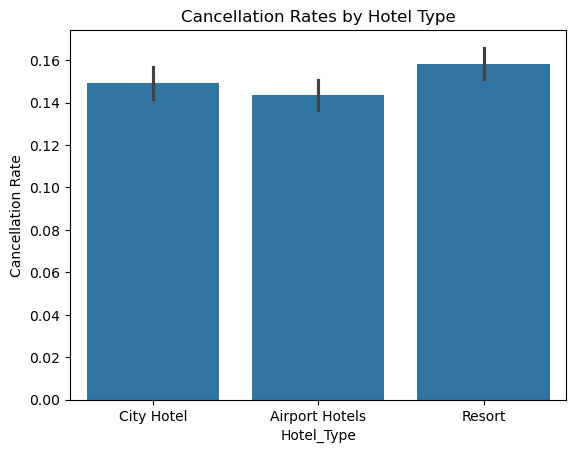

In [31]:
# Cancellation rate by hotel type
sns.barplot(x="Hotel_Type", 
            y=(train["Reservation_Status"]=="Canceled").astype(int), 
            data=train)
plt.title("Cancellation Rates by Hotel Type")
plt.ylabel("Cancellation Rate")
plt.show()

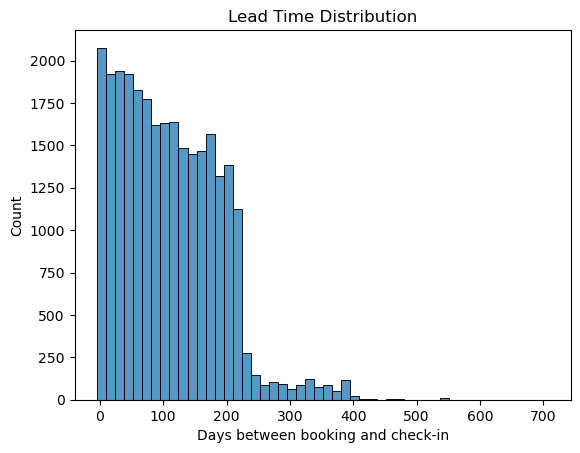

In [33]:
# lead time (days between booking and check-in)
train["Lead_Time"] = (pd.to_datetime(train["Expected_checkin"]) - 
                      pd.to_datetime(train["Booking_date"])).dt.days

sns.histplot(train["Lead_Time"], bins=50)
plt.title("Lead Time Distribution")
plt.xlabel("Days between booking and check-in")
plt.show()

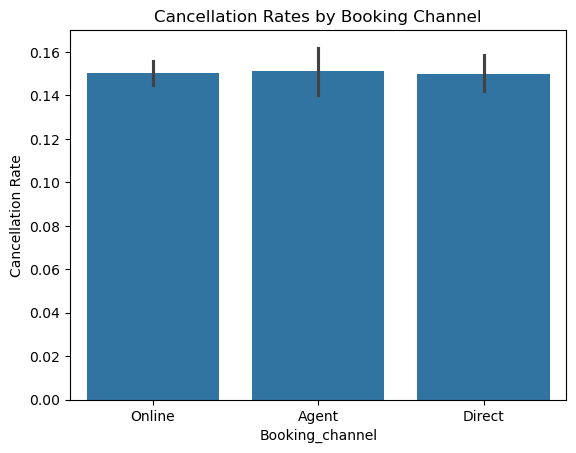

In [43]:
#Booking chanels VS Cancellation rate
sns.barplot(x="Booking_channel", 
            y=(train["Reservation_Status"]=="Canceled").astype(int), 
            data=train)
plt.title("Cancellation Rates by Booking Channel")
plt.ylabel("Cancellation Rate")
plt.show()

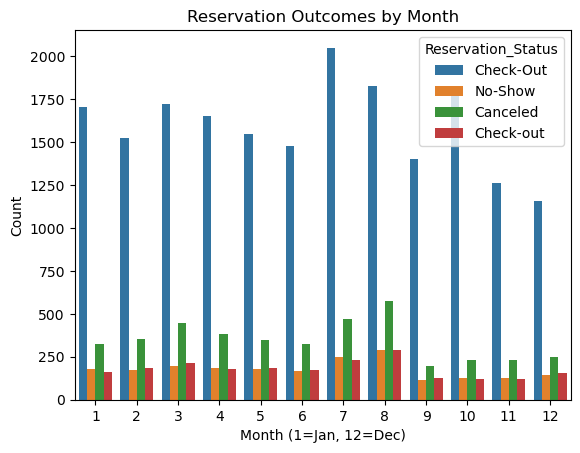

In [47]:
#Seasonality (Month VS reservation status)
# Extract month from check-in date
train["Month"] = pd.to_datetime(train["Expected_checkin"]).dt.month

sns.countplot(x="Month", hue="Reservation_Status", data=train)
plt.title("Reservation Outcomes by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Count")
plt.show()